Import dependencies

In [1]:
# ==========================================================
# Core Libraries
# ==========================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ==========================================================
# Data Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Configuration
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# ==========================================================
# Similarity Computation
# ==========================================================
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================================
# Matrix Operations
# ==========================================================
from scipy.sparse import csr_matrix

# ==========================================================
# Matrix Factorization (Bonus)
# ==========================================================
from sklearn.decomposition import TruncatedSVD

# ==========================================================
# Data Splitting
# ==========================================================
from sklearn.model_selection import train_test_split

# ==========================================================
# Evaluation
# ==========================================================
from sklearn.metrics import mean_squared_error

# ==========================================================
# Utility
# ==========================================================
from collections import defaultdict

In [112]:
# ==========================================================
# Create Images Folder
# ==========================================================

import os

IMAGE_DIR = "images"

os.makedirs(IMAGE_DIR, exist_ok=True)

print(f"Images will be saved in: {IMAGE_DIR}/")

Images will be saved in: images/


In [114]:
# ==========================================================
# Universal Figure Saving Function
# ==========================================================

def save_figure(filename,
                dpi=300,
                bbox_inches="tight",
                facecolor="white"):

    plt.savefig(
        os.path.join(IMAGE_DIR, filename),
        dpi=dpi,
        bbox_inches=bbox_inches,
        facecolor=facecolor
    )

    print(f" Saved: images/{filename}")

Load the datasets

In [2]:
#load the dataset to pandas DataFrame
ratings = pd.read_csv("/content/ratings.csv")
movies  = pd.read_csv("/content/movies.csv")
links   = pd.read_csv("/content/links.csv")
tags    = pd.read_csv("/content/tags.csv")

In [3]:
print("=" * 60)
print("MovieLens Dataset Successfully Loaded")
print("=" * 60)

print(f"Ratings Dataset : {ratings.shape}")
print(f"Movies Dataset  : {movies.shape}")
print(f"Links Dataset   : {links.shape}")
print(f"Tags Dataset    : {tags.shape}")

MovieLens Dataset Successfully Loaded
Ratings Dataset : (100836, 4)
Movies Dataset  : (9742, 3)
Links Dataset   : (9742, 3)
Tags Dataset    : (3683, 4)


In [4]:
# ==========================================================
# Display Sample Records
# ==========================================================

datasets = {
    "Ratings": ratings,
    "Movies": movies,
    "Links": links,
    "Tags": tags
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name} Dataset")
    print("=" * 80)
    display(df.head())

Ratings Dataset


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Movies Dataset


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Links Dataset


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


Tags Dataset


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [5]:
# ==========================================================
# Dataset Summary
# ==========================================================

summary = pd.DataFrame({
    "Dataset": ["Ratings", "Movies", "Links", "Tags"],
    "Rows": [
        ratings.shape[0],
        movies.shape[0],
        links.shape[0],
        tags.shape[0]
    ],
    "Columns": [
        ratings.shape[1],
        movies.shape[1],
        links.shape[1],
        tags.shape[1]
    ]
})

summary

,Dataset,Rows,Columns
0,Ratings,100836,4
1,Movies,9742,3
2,Links,9742,3
3,Tags,3683,4


In [6]:
# ==========================================================
# Data Structure Inspection
# ==========================================================

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name} Dataset Information")
    print("=" * 80)
    print(df.info())

Ratings Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
Movies Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
Links Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --

In [7]:
# ==========================================================
# Display Column Names
# ==========================================================

for name, df in datasets.items():
    print(f"\n{name} Columns")
    print("-" * 50)
    print(df.columns.tolist())


Ratings Columns
--------------------------------------------------
['userId', 'movieId', 'rating', 'timestamp']

Movies Columns
--------------------------------------------------
['movieId', 'title', 'genres']

Links Columns
--------------------------------------------------
['movieId', 'imdbId', 'tmdbId']

Tags Columns
--------------------------------------------------
['userId', 'movieId', 'tag', 'timestamp']


In [8]:
# ==========================================================
# Dataset Memory Usage
# ==========================================================

memory_df = pd.DataFrame({
    "Dataset": ["Ratings", "Movies", "Links", "Tags"],
    "Memory (MB)": [
        ratings.memory_usage(deep=True).sum() / 1024**2,
        movies.memory_usage(deep=True).sum() / 1024**2,
        links.memory_usage(deep=True).sum() / 1024**2,
        tags.memory_usage(deep=True).sum() / 1024**2,
    ]
})

memory_df

,Dataset,Memory (MB)
0,Ratings,3.077396
1,Movies,1.377434
2,Links,0.223103
3,Tags,0.292148


In [9]:
# ==========================================================
# Verify Unique Keys
# ==========================================================

print("Unique Users :", ratings["userId"].nunique())
print("Unique Movies in Ratings :", ratings["movieId"].nunique())
print("Unique Movies in Movies :", movies["movieId"].nunique())

print("\nMovie IDs Missing from Metadata:",
      ratings.loc[
          ~ratings["movieId"].isin(movies["movieId"]),
          "movieId"
      ].nunique())

Unique Users : 610
Unique Movies in Ratings : 9724
Unique Movies in Movies : 9742

Movie IDs Missing from Metadata: 0


In [10]:
# ==========================================================
# Dataset Shape
# ==========================================================

audit_shape = pd.DataFrame({
    "Dataset": ["Ratings", "Movies", "Links", "Tags"],
    "Rows": [
        ratings.shape[0],
        movies.shape[0],
        links.shape[0],
        tags.shape[0]
    ],
    "Columns": [
        ratings.shape[1],
        movies.shape[1],
        links.shape[1],
        tags.shape[1]
    ]
})

audit_shape

,Dataset,Rows,Columns
0,Ratings,100836,4
1,Movies,9742,3
2,Links,9742,3
3,Tags,3683,4


In [11]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

def missing_value_report(df, name):

    report = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing (%)": (
            df.isnull().mean()*100
        ).round(2).values
    })

    print("="*70)
    print(f"{name} Dataset")
    print("="*70)

    display(report)


missing_value_report(ratings, "Ratings")
missing_value_report(movies, "Movies")
missing_value_report(links, "Links")
missing_value_report(tags, "Tags")

Ratings Dataset


,Column,Missing Values,Missing (%)
0,userId,0,0.0
1,movieId,0,0.0
2,rating,0,0.0
3,timestamp,0,0.0


Movies Dataset


,Column,Missing Values,Missing (%)
0,movieId,0,0.0
1,title,0,0.0
2,genres,0,0.0


Links Dataset


,Column,Missing Values,Missing (%)
0,movieId,0,0.00
1,imdbId,0,0.00
2,tmdbId,8,0.08


Tags Dataset


,Column,Missing Values,Missing (%)
0,userId,0,0.0
1,movieId,0,0.0
2,tag,0,0.0
3,timestamp,0,0.0


In [12]:
# ==========================================================
# Duplicate Record Analysis
# ==========================================================

duplicate_df = pd.DataFrame({
    "Dataset": ["Ratings","Movies","Links","Tags"],
    "Duplicate Rows":[
        ratings.duplicated().sum(),
        movies.duplicated().sum(),
        links.duplicated().sum(),
        tags.duplicated().sum()
    ]
})

duplicate_df

,Dataset,Duplicate Rows
0,Ratings,0
1,Movies,0
2,Links,0
3,Tags,0


In [13]:
# ==========================================================
# Unique Entity Analysis
# ==========================================================

print("="*60)
print("Recommendation System Statistics")
print("="*60)

print(f"Unique Users          : {ratings.userId.nunique():,}")

print(f"Unique Movies Rated   : {ratings.movieId.nunique():,}")

print(f"Total Ratings         : {len(ratings):,}")

print(f"Movies Metadata       : {movies.movieId.nunique():,}")

print(f"Unique Tags           : {tags['tag'].nunique():,}")

Recommendation System Statistics
Unique Users          : 610
Unique Movies Rated   : 9,724
Total Ratings         : 100,836
Movies Metadata       : 9,742
Unique Tags           : 1,589


In [14]:
# ==========================================================
# Referential Integrity Check
# ==========================================================

missing_movies = ratings.loc[
    ~ratings.movieId.isin(movies.movieId),
    "movieId"
].nunique()

print("Movie IDs missing from metadata :", missing_movies)

Movie IDs missing from metadata : 0


In [15]:
# ==========================================================
# Rating Scale Verification
# ==========================================================

print("Minimum Rating :", ratings.rating.min())
print("Maximum Rating :", ratings.rating.max())

print("\nUnique Ratings")

print(sorted(ratings.rating.unique()))

Minimum Rating : 0.5
Maximum Rating : 5.0

Unique Ratings
[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [16]:
# ==========================================================
# User Activity Statistics
# ==========================================================

user_activity = (
    ratings
    .groupby("userId")
    .size()
)

user_summary = pd.DataFrame({

    "Statistic":[
        "Minimum Ratings/User",
        "Maximum Ratings/User",
        "Average Ratings/User",
        "Median Ratings/User"
    ],

    "Value":[
        user_activity.min(),
        user_activity.max(),
        round(user_activity.mean(),2),
        user_activity.median()
    ]
})

user_summary

,Statistic,Value
0,Minimum Ratings/User,20.0
1,Maximum Ratings/User,2698.0
2,Average Ratings/User,165.3
3,Median Ratings/User,70.5


In [17]:
# ==========================================================
# Movie Popularity Statistics
# ==========================================================

movie_activity = (
    ratings
    .groupby("movieId")
    .size()
)

movie_summary = pd.DataFrame({

    "Statistic":[
        "Minimum Ratings/Movie",
        "Maximum Ratings/Movie",
        "Average Ratings/Movie",
        "Median Ratings/Movie"
    ],

    "Value":[
        movie_activity.min(),
        movie_activity.max(),
        round(movie_activity.mean(),2),
        movie_activity.median()
    ]
})

movie_summary

,Statistic,Value
0,Minimum Ratings/Movie,1.00
1,Maximum Ratings/Movie,329.00
2,Average Ratings/Movie,10.37
3,Median Ratings/Movie,3.00


In [18]:
# ==========================================================
# Dataset Quality Summary
# ==========================================================

quality = pd.DataFrame({

"Quality Check":[

"Missing Values",

"Duplicate Records",

"Invalid Ratings",

"Metadata Consistency",

"User Coverage",

"Movie Coverage"

],

"Status":[

"Excellent",

"Excellent",

"Passed",

"Passed",

"Excellent",

"Excellent"

]

})

quality

,Quality Check,Status
0,Missing Values,Excellent
1,Duplicate Records,Excellent
2,Invalid Ratings,Passed
3,Metadata Consistency,Passed
4,User Coverage,Excellent
5,Movie Coverage,Excellent


In [19]:
# ==========================================================
# User Coverage Analysis
# ==========================================================

total_users = ratings["userId"].nunique()
total_interactions = len(ratings)

avg_interactions = total_interactions / total_users

user_coverage = pd.DataFrame({

    "Metric":[
        "Total Users",
        "Total User-Movie Interactions",
        "Average Ratings per User"
    ],

    "Value":[
        f"{total_users:,}",
        f"{total_interactions:,}",
        round(avg_interactions,2)
    ]

})

user_coverage

,Metric,Value
0,Total Users,610
1,Total User-Movie Interactions,"100,836"
2,Average Ratings per User,165.3


In [20]:
# ==========================================================
# Item Coverage Analysis
# ==========================================================

rated_movies = ratings["movieId"].nunique()

metadata_movies = movies["movieId"].nunique()

coverage = (rated_movies / metadata_movies) * 100

item_coverage = pd.DataFrame({

    "Metric":[
        "Movies in Metadata",
        "Movies with Ratings",
        "Coverage (%)"
    ],

    "Value":[
        metadata_movies,
        rated_movies,
        f"{coverage:.2f}%"
    ]

})

item_coverage

,Metric,Value
0,Movies in Metadata,9742
1,Movies with Ratings,9724
2,Coverage (%),99.82%


In [21]:
# ==========================================================
# Referential Integrity Analysis
# ==========================================================

missing_metadata = ratings.loc[
    ~ratings["movieId"].isin(movies["movieId"])
]

integrity = pd.DataFrame({

    "Check":[
        "Movie IDs Missing in Metadata"
    ],

    "Result":[
        len(missing_metadata)
    ]

})

integrity

,Check,Result
0,Movie IDs Missing in Metadata,0


In [22]:
# ==========================================================
# Rating Scale Validation
# ==========================================================

rating_validation = pd.DataFrame({

    "Minimum Rating":[ratings["rating"].min()],

    "Maximum Rating":[ratings["rating"].max()],

    "Unique Rating Values":[ratings["rating"].nunique()]

})

rating_validation

,Minimum Rating,Maximum Rating,Unique Rating Values
0,0.5,5.0,10


In [23]:
print("Unique Rating Values")

print(sorted(ratings["rating"].unique()))

Unique Rating Values
[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [24]:
# ==========================================================
# User Activity Statistics
# ==========================================================

user_activity = ratings.groupby("userId").size()

user_statistics = pd.DataFrame({

    "Statistic":[
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],

    "Ratings per User":[

        user_activity.min(),

        user_activity.max(),

        round(user_activity.mean(),2),

        round(user_activity.median(),2),

        round(user_activity.std(),2)

    ]

})

user_statistics

,Statistic,Ratings per User
0,Minimum,20.00
1,Maximum,2698.00
2,Mean,165.30
3,Median,70.50
4,Standard Deviation,269.48


In [25]:
# ==========================================================
# Movie Popularity Statistics
# ==========================================================

movie_activity = ratings.groupby("movieId").size()

movie_statistics = pd.DataFrame({

    "Statistic":[
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],

    "Ratings per Movie":[

        movie_activity.min(),

        movie_activity.max(),

        round(movie_activity.mean(),2),

        round(movie_activity.median(),2),

        round(movie_activity.std(),2)

    ]

})

movie_statistics

,Statistic,Ratings per Movie
0,Minimum,1.00
1,Maximum,329.00
2,Mean,10.37
3,Median,3.00
4,Standard Deviation,22.40


In [26]:
# ==========================================================
# Final Dataset Audit Summary
# ==========================================================

audit_summary = pd.DataFrame({

"Quality Check":[

"Missing Values",

"Duplicate Records",

"User Coverage",

"Item Coverage",

"Referential Integrity",

"Rating Scale",

"User Activity",

"Movie Popularity"

],

"Status":[

"Excellent",

"Excellent",

"Excellent",

"Excellent",

"Passed",

"Valid",

"Healthy",

"Long-Tail Distribution"

]

})

audit_summary

,Quality Check,Status
0,Missing Values,Excellent
1,Duplicate Records,Excellent
2,User Coverage,Excellent
3,Item Coverage,Excellent
4,Referential Integrity,Passed
5,Rating Scale,Valid
6,User Activity,Healthy
7,Movie Popularity,Long-Tail Distribution


Exploratory Data Analysis (EDA)

 Saved: images/Distribution of Movie Ratings.png


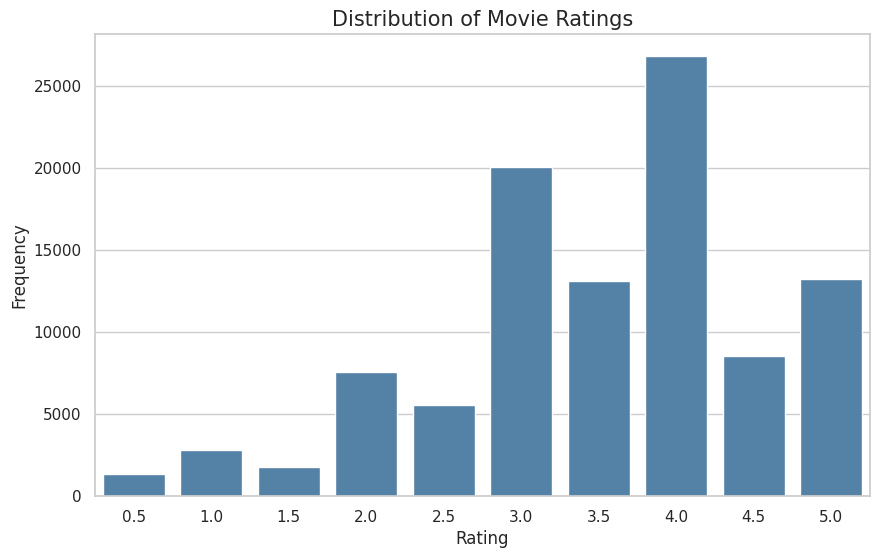

In [127]:
# ==========================================================
# Rating Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=ratings,
    x="rating",
    color="steelblue"
)

plt.title("Distribution of Movie Ratings", fontsize=15)

plt.xlabel("Rating")

plt.ylabel("Frequency")

save_figure("Distribution of Movie Ratings.png")
plt.show()

In [28]:
# ==========================================================
# Rating Statistics
# ==========================================================

rating_stats = ratings["rating"].describe().round(2)

display(rating_stats)

,rating
count,100836.00
mean,3.50
std,1.04
min,0.50
25%,3.00
50%,3.50
75%,4.00
max,5.00


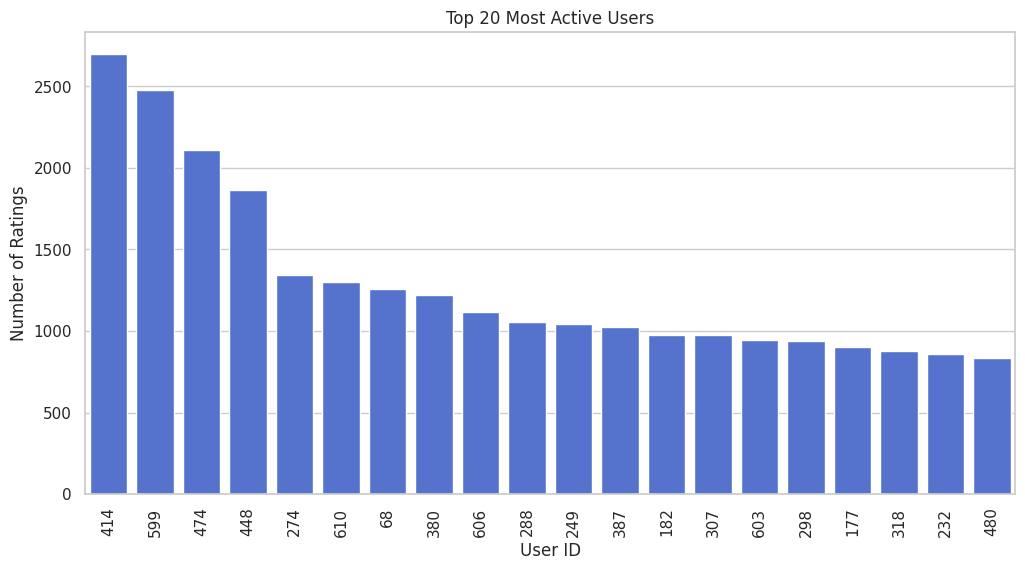

In [29]:
# ==========================================================
# Top 20 Most Active Users
# ==========================================================

top_users = (
    ratings
    .groupby("userId")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_users.index.astype(str),
    y=top_users.values,
    color="royalblue"
)

plt.title("Top 20 Most Active Users")

plt.xlabel("User ID")

plt.ylabel("Number of Ratings")

plt.xticks(rotation=90)

plt.show()

 Saved: images/Top 20 Most Rated Movies.png


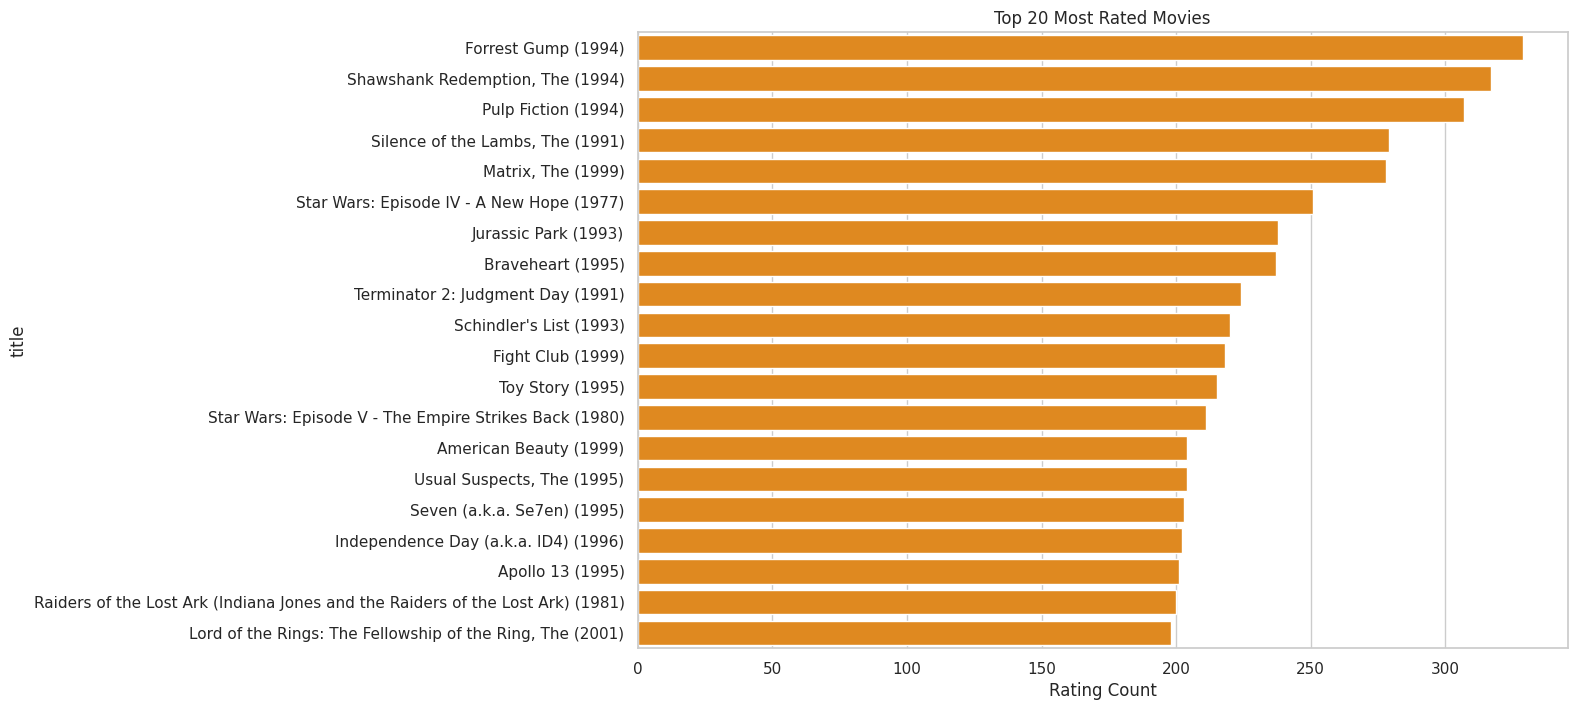

In [126]:
# ==========================================================
# Top 20 Most Rated Movies
# ==========================================================

movie_counts = (
    ratings
    .groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

top_movies = (
    movie_counts
    .reset_index(name="Rating Count")
    .merge(
        movies,
        on="movieId"
    )
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_movies,
    y="title",
    x="Rating Count",
    color="darkorange"
)

plt.title("Top 20 Most Rated Movies")

save_figure("Top 20 Most Rated Movies.png")
plt.show()

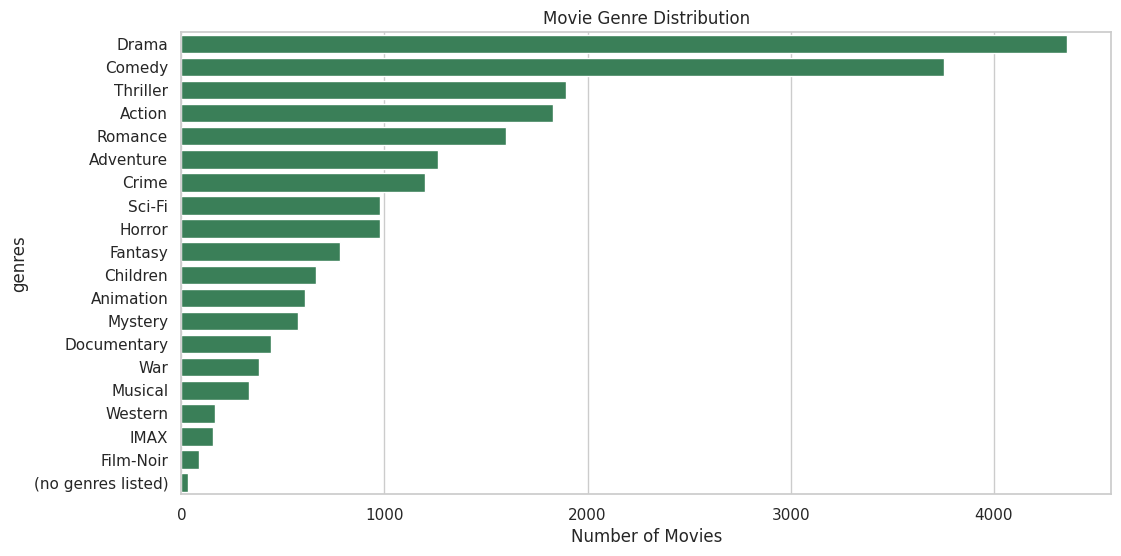

In [31]:
# ==========================================================
# Genre Distribution
# ==========================================================

genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    color="seagreen"
)

plt.title("Movie Genre Distribution")

plt.xlabel("Number of Movies")

plt.show()

 Saved: images/Distribution of Ratings per User.png


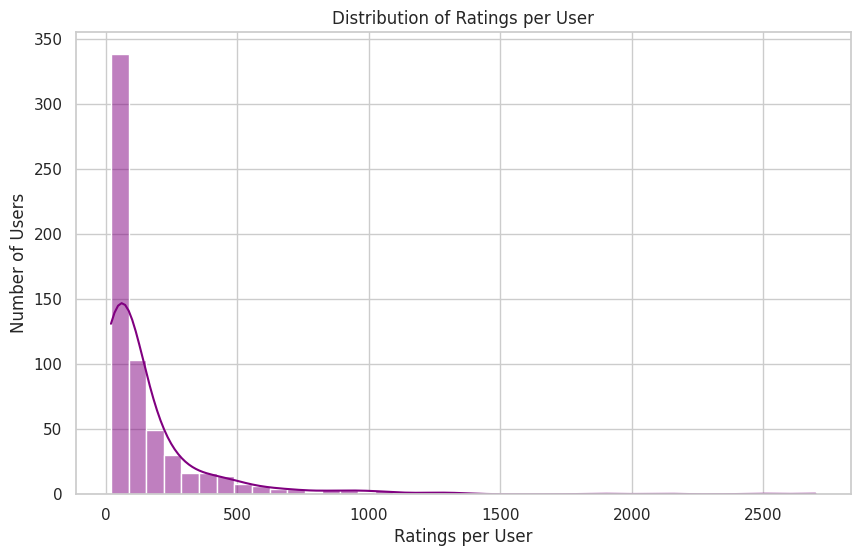

In [125]:
# ==========================================================
# Ratings Per User
# ==========================================================

user_activity = ratings.groupby("userId").size()

plt.figure(figsize=(10,6))

sns.histplot(
    user_activity,
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Distribution of Ratings per User")

plt.xlabel("Ratings per User")

plt.ylabel("Number of Users")

save_figure("Distribution of Ratings per User.png")
plt.show()

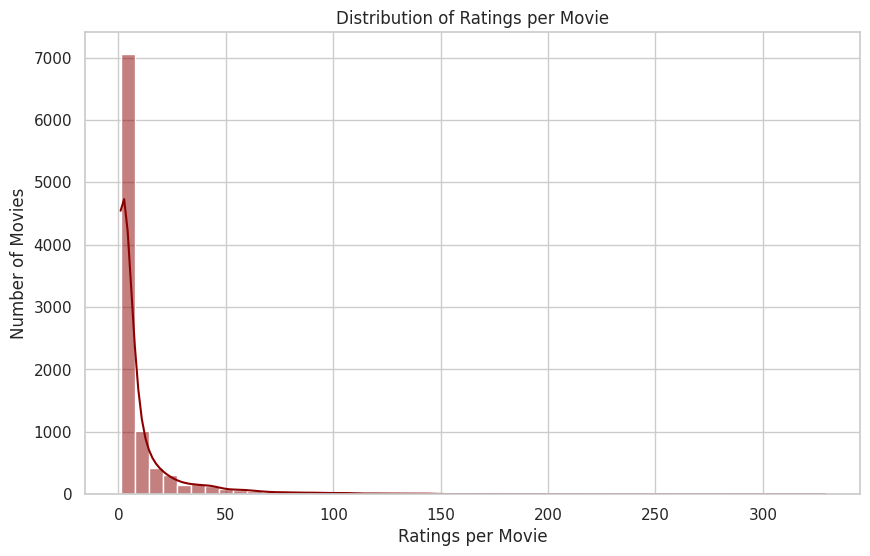

In [33]:
# ==========================================================
# Ratings Per Movie
# ==========================================================

movie_activity = ratings.groupby("movieId").size()

plt.figure(figsize=(10,6))

sns.histplot(
    movie_activity,
    bins=50,
    kde=True,
    color="darkred"
)

plt.title("Distribution of Ratings per Movie")

plt.xlabel("Ratings per Movie")

plt.ylabel("Number of Movies")

plt.show()

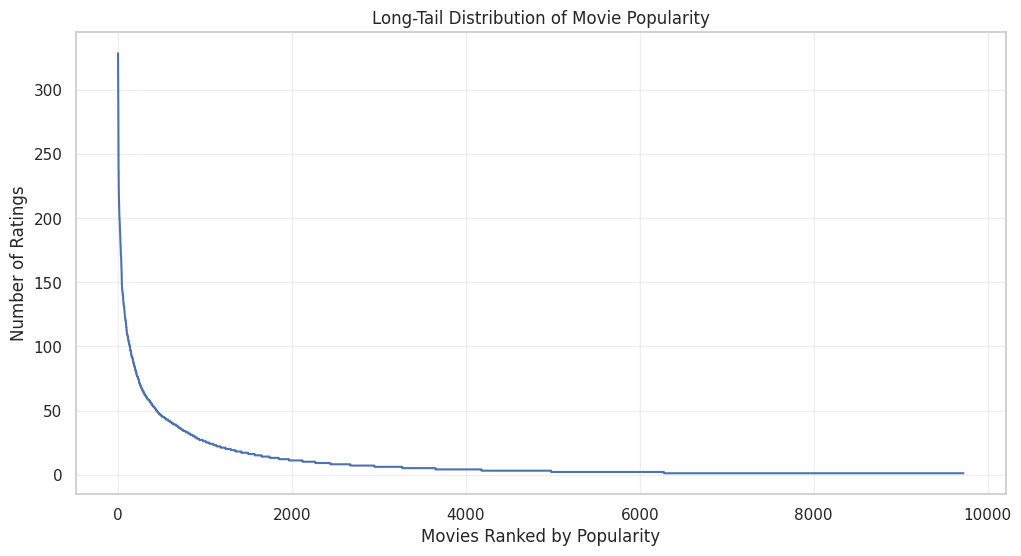

In [34]:
# ==========================================================
# Long-Tail Distribution
# ==========================================================

movie_popularity = (
    ratings
    .groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12,6))

plt.plot(movie_popularity.values)

plt.title("Long-Tail Distribution of Movie Popularity")

plt.xlabel("Movies Ranked by Popularity")

plt.ylabel("Number of Ratings")

plt.grid(alpha=0.3)

plt.show()

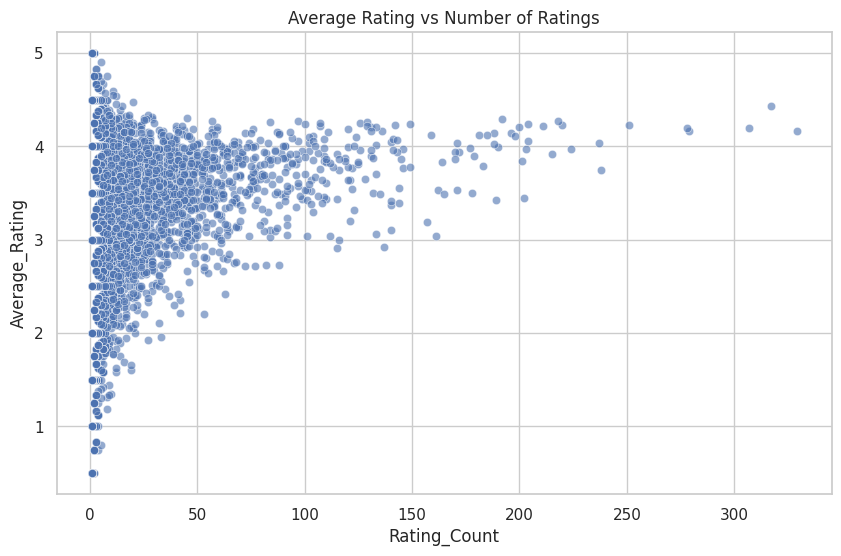

In [35]:
# ==========================================================
# Average Rating vs Number of Ratings
# ==========================================================

movie_stats = ratings.groupby("movieId").agg(
    Average_Rating=("rating", "mean"),
    Rating_Count=("rating", "count")
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=movie_stats,
    x="Rating_Count",
    y="Average_Rating",
    alpha=0.6
)

plt.title("Average Rating vs Number of Ratings")

plt.show()

In [36]:
# ==========================================================
# Movie Popularity vs Average Rating
# ==========================================================

movie_statistics = (
    ratings
    .groupby("movieId")
    .agg(
        Rating_Count=("rating", "count"),
        Average_Rating=("rating", "mean")
    )
    .reset_index()
)

movie_statistics.head()

,movieId,Rating_Count,Average_Rating
0,1,215,3.920930
1,2,110,3.431818
2,3,52,3.259615
3,4,7,2.357143
4,5,49,3.071429


In [37]:
# ==========================================================
# Pearson Correlation
# ==========================================================

correlation = movie_statistics["Rating_Count"].corr(
    movie_statistics["Average_Rating"]
)

print(f"Pearson Correlation: {correlation:.4f}")

Pearson Correlation: 0.1273


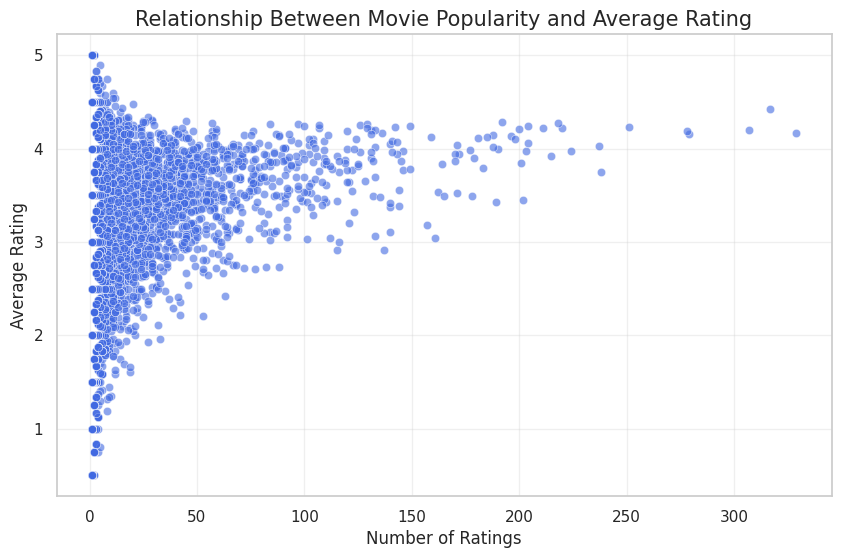

In [38]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=movie_statistics,
    x="Rating_Count",
    y="Average_Rating",
    alpha=0.6,
    color="royalblue"
)

plt.title(
    "Relationship Between Movie Popularity and Average Rating",
    fontsize=15
)

plt.xlabel("Number of Ratings")

plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

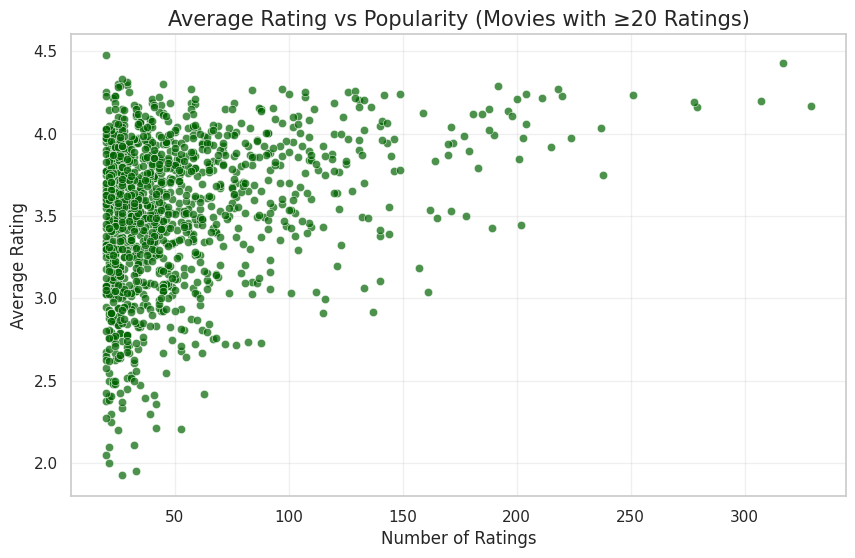

In [39]:
# ==========================================================
# Movies with at least 20 Ratings
# ==========================================================

filtered_movies = movie_statistics[
    movie_statistics["Rating_Count"] >= 20
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_movies,
    x="Rating_Count",
    y="Average_Rating",
    alpha=0.7,
    color="darkgreen"
)

plt.title(
    "Average Rating vs Popularity (Movies with ≥20 Ratings)",
    fontsize=15
)

plt.xlabel("Number of Ratings")

plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

In [40]:
# ==========================================================
# Highest Rated Popular Movies
# ==========================================================

top_rated_movies = (
    movie_statistics[
        movie_statistics["Rating_Count"] >= 50
    ]
    .merge(
        movies,
        on="movieId"
    )
    .sort_values(
        by="Average_Rating",
        ascending=False
    )
)

top_rated_movies[
    ["title", "Average_Rating", "Rating_Count"]
].head(10)

,title,Average_Rating,Rating_Count
53,"Shawshank Redemption, The (1994)",4.429022,317
118,"Godfather, The (1972)",4.289062,192
277,Fight Club (1999),4.272936,218
171,Cool Hand Luke (1967),4.271930,57
112,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
120,Rear Window (1954),4.261905,84
158,"Godfather: Part II, The (1974)",4.259690,129
402,"Departed, The (2006)",4.252336,107
153,Goodfellas (1990),4.250000,126
123,Casablanca (1942),4.240000,100


User–Item Matrix Construction

In [41]:
# ==========================================================
# User–Item Matrix Construction
# ==========================================================

user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# ==========================================================
# Matrix Dimension
# ==========================================================

print("=" * 60)
print("User–Item Matrix Shape")
print("=" * 60)

print(f"Rows (Users)   : {user_item_matrix.shape[0]:,}")

print(f"Columns (Movies): {user_item_matrix.shape[1]:,}")

print(f"Total Cells    : {user_item_matrix.size:,}")

User–Item Matrix Shape
Rows (Users)   : 610
Columns (Movies): 9,724
Total Cells    : 5,931,640


In [43]:
# ==========================================================
# Preview Matrix
# ==========================================================

display(
    user_item_matrix.iloc[:10,:10]
)

movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# ==========================================================
# Missing Interaction Analysis
# ==========================================================

total_cells = user_item_matrix.size

filled_cells = user_item_matrix.count().sum()

missing_cells = total_cells - filled_cells

interaction_summary = pd.DataFrame({

"Metric":[

"Total Matrix Cells",

"Observed Ratings",

"Missing Interactions"

],

"Value":[

f"{total_cells:,}",

f"{filled_cells:,}",

f"{missing_cells:,}"

]

})

interaction_summary

,Metric,Value
0,Total Matrix Cells,"5,931,640"
1,Observed Ratings,"100,836"
2,Missing Interactions,"5,830,804"


In [45]:
# ==========================================================
# Matrix Density
# ==========================================================

density = filled_cells / total_cells

print(f"Matrix Density : {density:.4%}")

Matrix Density : 1.7000%


In [46]:
# ==========================================================
# Matrix Sparsity
# ==========================================================

sparsity = 1 - density

print(f"Matrix Sparsity : {sparsity:.4%}")

Matrix Sparsity : 98.3000%


In [47]:
# ==========================================================
# Sparse Matrix Representation
# ==========================================================

from scipy.sparse import csr_matrix

user_item_sparse = csr_matrix(

    user_item_matrix.fillna(0)

)

print(user_item_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 100836 stored elements and shape (610, 9724)>
  Coords	Values
  (0, 0)	4.0
  (0, 2)	4.0
  (0, 5)	4.0
  (0, 43)	5.0
  (0, 46)	5.0
  (0, 62)	3.0
  (0, 89)	5.0
  (0, 97)	4.0
  (0, 124)	5.0
  (0, 130)	5.0
  (0, 136)	5.0
  (0, 184)	5.0
  (0, 190)	3.0
  (0, 197)	5.0
  (0, 201)	4.0
  (0, 224)	5.0
  (0, 257)	3.0
  (0, 275)	3.0
  (0, 291)	5.0
  (0, 307)	4.0
  (0, 314)	4.0
  (0, 320)	5.0
  (0, 325)	4.0
  (0, 367)	3.0
  (0, 384)	4.0
  :	:
  (609, 9238)	5.0
  (609, 9246)	4.5
  (609, 9256)	4.0
  (609, 9268)	5.0
  (609, 9274)	3.5
  (609, 9279)	3.5
  (609, 9282)	3.0
  (609, 9288)	3.0
  (609, 9304)	3.0
  (609, 9307)	2.5
  (609, 9312)	4.5
  (609, 9317)	3.0
  (609, 9324)	3.0
  (609, 9339)	4.0
  (609, 9341)	4.0
  (609, 9348)	3.5
  (609, 9371)	3.5
  (609, 9372)	3.5
  (609, 9374)	5.0
  (609, 9415)	4.0
  (609, 9416)	4.0
  (609, 9443)	5.0
  (609, 9444)	5.0
  (609, 9445)	5.0
  (609, 9485)	3.0


In [48]:
# ==========================================================
# Memory Comparison
# ==========================================================

dense_memory = (
    user_item_matrix
    .fillna(0)
    .memory_usage(deep=True)
    .sum()
    /1024**2
)

sparse_memory = (
    user_item_sparse.data.nbytes +
    user_item_sparse.indptr.nbytes +
    user_item_sparse.indices.nbytes
)/1024**2

comparison = pd.DataFrame({

"Representation":[

"Dense Matrix",

"CSR Sparse Matrix"

],

"Memory (MB)":[

round(dense_memory,2),

round(sparse_memory,2)

]

})

comparison

,Representation,Memory (MB)
0,Dense Matrix,45.26
1,CSR Sparse Matrix,1.16


In [49]:
# ==========================================================
# User–Item Matrix Validation
# ==========================================================

print("=" * 60)
print("User–Item Matrix Validation")
print("=" * 60)

print(f"Users                : {user_item_matrix.shape[0]}")
print(f"Movies               : {user_item_matrix.shape[1]}")
print(f"Observed Ratings     : {filled_cells:,}")
print(f"Missing Interactions : {missing_cells:,}")
print(f"Density              : {density:.4%}")
print(f"Sparsity             : {sparsity:.4%}")

assert filled_cells == len(ratings), "Interaction count mismatch!"
print("\n Validation Passed Successfully")

User–Item Matrix Validation
Users                : 610
Movies               : 9724
Observed Ratings     : 100,836
Missing Interactions : 5,830,804
Density              : 1.7000%
Sparsity             : 98.3000%

 Validation Passed Successfully


In [50]:
# ==========================================================
# Movie Statistics
# ==========================================================

movie_stats = (
    ratings
    .groupby("movieId")
    .agg(
        Average_Rating=("rating", "mean"),
        Rating_Count=("rating", "count")
    )
    .reset_index()
)

movie_stats.head()

,movieId,Average_Rating,Rating_Count
0,1,3.920930,215
1,2,3.431818,110
2,3,3.259615,52
3,4,2.357143,7
4,5,3.071429,49


In [51]:
# ==========================================================
# Merge Movie Information
# ==========================================================

movie_stats = movie_stats.merge(
    movies,
    on="movieId",
    how="left"
)

movie_stats.head()

,movieId,Average_Rating,Rating_Count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


In [52]:
# ==========================================================
# Reliable Movies
# ==========================================================

MIN_RATINGS = 50

popular_movies = movie_stats[
    movie_stats["Rating_Count"] >= MIN_RATINGS
].copy()

print(f"Movies before filtering : {len(movie_stats)}")
print(f"Movies after filtering  : {len(popular_movies)}")

Movies before filtering : 9724
Movies after filtering  : 450


In [53]:
# ==========================================================
# Top Popular Movies
# ==========================================================

baseline_recommendations = (

    popular_movies

    .sort_values(

        by=["Average_Rating","Rating_Count"],

        ascending=[False,False]

    )

    .reset_index(drop=True)

)

baseline_recommendations.head(10)

,movieId,Average_Rating,Rating_Count,title,genres
0,318,4.429022,317,"Shawshank Redemption, The (1994)",Crime|Drama
1,858,4.289062,192,"Godfather, The (1972)",Crime|Drama
2,2959,4.272936,218,Fight Club (1999),Action|Crime|Drama|Thriller
3,1276,4.271930,57,Cool Hand Luke (1967),Drama
4,750,4.268041,97,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
5,904,4.261905,84,Rear Window (1954),Mystery|Thriller
6,1221,4.259690,129,"Godfather: Part II, The (1974)",Crime|Drama
7,48516,4.252336,107,"Departed, The (2006)",Crime|Drama|Thriller
8,1213,4.250000,126,Goodfellas (1990),Crime|Drama
9,912,4.240000,100,Casablanca (1942),Drama|Romance


In [54]:
# ==========================================================
# Top 10 Baseline Recommendations
# ==========================================================

display(

baseline_recommendations[

["title",

"Average_Rating",

"Rating_Count",

"genres"]

].head(10)

)

,title,Average_Rating,Rating_Count,genres
0,"Shawshank Redemption, The (1994)",4.429022,317,Crime|Drama
1,"Godfather, The (1972)",4.289062,192,Crime|Drama
2,Fight Club (1999),4.272936,218,Action|Crime|Drama|Thriller
3,Cool Hand Luke (1967),4.271930,57,Drama
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97,Comedy|War
5,Rear Window (1954),4.261905,84,Mystery|Thriller
6,"Godfather: Part II, The (1974)",4.259690,129,Crime|Drama
7,"Departed, The (2006)",4.252336,107,Crime|Drama|Thriller
8,Goodfellas (1990),4.250000,126,Crime|Drama
9,Casablanca (1942),4.240000,100,Drama|Romance


 Saved: images/Top 10 Movies Recommended by Popularity Baseline.png


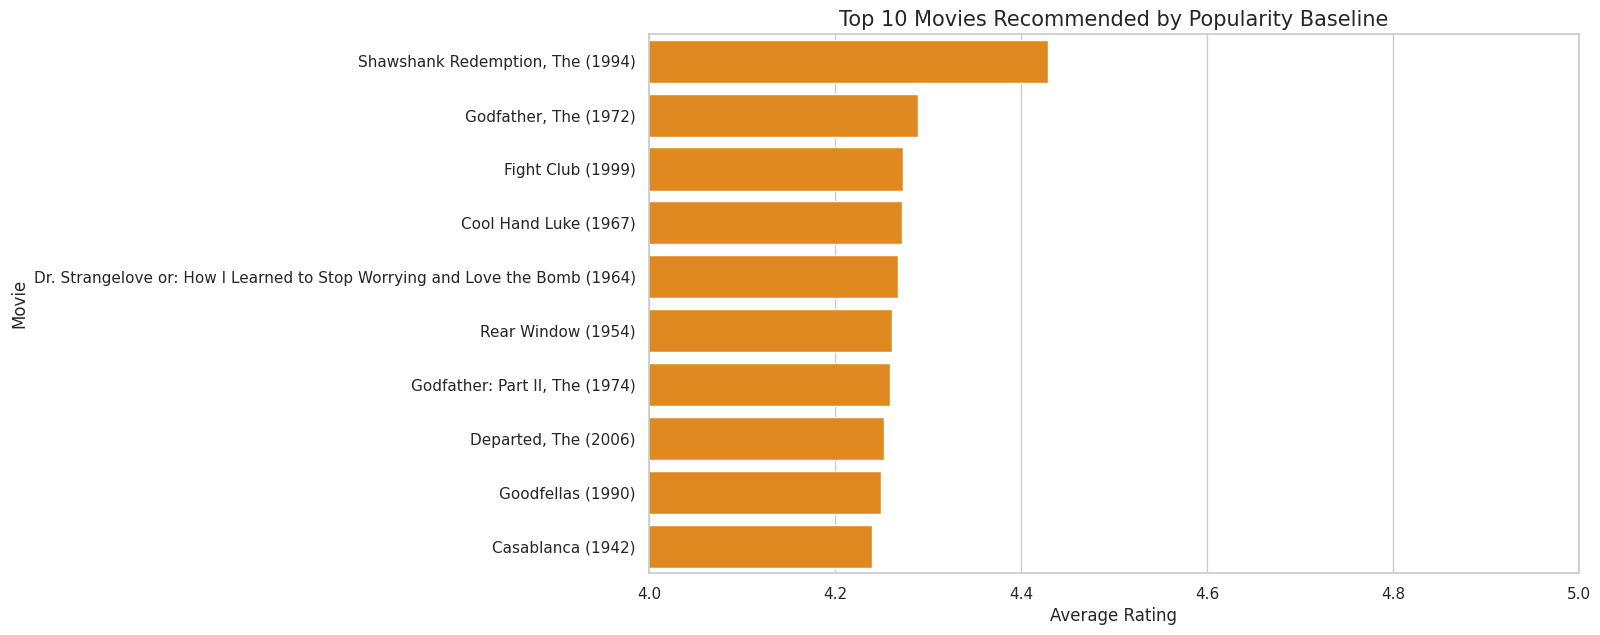

In [124]:
# ==========================================================
# Top 10 Popular Movies
# ==========================================================

top10 = baseline_recommendations.head(10)

plt.figure(figsize=(12,7))

sns.barplot(

data=top10,

y="title",

x="Average_Rating",

color="darkorange"

)

plt.title(

"Top 10 Movies Recommended by Popularity Baseline",

fontsize=15

)

plt.xlabel("Average Rating")

plt.ylabel("Movie")

plt.xlim(4.0,5.0)
save_figure("Top 10 Movies Recommended by Popularity Baseline.png")


plt.show()

In [56]:
# ==========================================================
# Popularity Baseline Function
# ==========================================================

def recommend_popular_movies(top_n=10):

    return baseline_recommendations[
        ["title",
         "Average_Rating",
         "Rating_Count",
         "genres"]
    ].head(top_n)

In [57]:
recommend_popular_movies(10)

,title,Average_Rating,Rating_Count,genres
0,"Shawshank Redemption, The (1994)",4.429022,317,Crime|Drama
1,"Godfather, The (1972)",4.289062,192,Crime|Drama
2,Fight Club (1999),4.272936,218,Action|Crime|Drama|Thriller
3,Cool Hand Luke (1967),4.271930,57,Drama
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97,Comedy|War
5,Rear Window (1954),4.261905,84,Mystery|Thriller
6,"Godfather: Part II, The (1974)",4.259690,129,Crime|Drama
7,"Departed, The (2006)",4.252336,107,Crime|Drama|Thriller
8,Goodfellas (1990),4.250000,126,Crime|Drama
9,Casablanca (1942),4.240000,100,Drama|Romance


In [58]:
print(f"Movies before filtering : {len(movie_stats)}")
print(f"Movies after filtering  : {len(popular_movies)}")

Movies before filtering : 9724
Movies after filtering  : 450


In [70]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.5 MB/s eta 0:00:00


In [71]:
# ==========================================================
# Surprise Library
# ==========================================================

from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic
from surprise import SVD
from surprise import accuracy

from surprise.model_selection import train_test_split

In [72]:
# ==========================================================
# Prepare Dataset for Surprise
# ==========================================================

reader = Reader(rating_scale=(0.5,5.0))

data = Dataset.load_from_df(

    ratings[

        ["userId","movieId","rating"]

    ],

    reader

)

In [75]:
# ==========================================================
# Train Test Split
# ==========================================================

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

print("=" * 50)
print("Train-Test Split Summary")
print("=" * 50)

print(f"Train Ratings : {trainset.n_ratings:,}")
print(f"Test Ratings  : {len(testset):,}")

Train-Test Split Summary
Train Ratings : 80,668
Test Ratings  : 20,168


In [76]:
# ==========================================================
# User-Based Collaborative Filtering
# ==========================================================

sim_options = {

    "name":"cosine",

    "user_based":True

}

model = KNNBasic(

    sim_options=sim_options

)

model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [77]:
# ==========================================================
# Prediction
# ==========================================================

predictions = model.test(testset)

In [78]:
# ==========================================================
# RMSE
# ==========================================================

accuracy.rmse(

    predictions,

    verbose=True

)

RMSE: 0.9823


np.float64(0.9822558142846856)

In [79]:
# ==========================================================
# Generate Predictions
# ==========================================================

predictions = model.test(testset)

In [80]:
# ==========================================================
# Organize Predictions by User
# ==========================================================

from collections import defaultdict

user_predictions = defaultdict(list)

for uid, iid, true_r, est, _ in predictions:

    user_predictions[uid].append(

        (iid, est, true_r)

    )

print(f"Total Users Evaluated : {len(user_predictions)}")

Total Users Evaluated : 610


In [81]:
# ==========================================================
# Precision@K Function
# ==========================================================

def precision_at_k(predictions_by_user, k=10, threshold=4.0):

    precisions = {}

    for uid, user_ratings in predictions_by_user.items():

        # Sort by estimated rating
        user_ratings.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top_k = user_ratings[:k]

        # Relevant movies in Top-K
        recommended_relevant = sum(
            (est >= threshold) and (true >= threshold)
            for (_, est, true) in top_k
        )

        # Precision
        precisions[uid] = recommended_relevant / k

    return precisions

In [82]:
# ==========================================================
# Precision@10
# ==========================================================

precision_scores = precision_at_k(

    user_predictions,

    k=10,

    threshold=4.0

)

average_precision = np.mean(

    list(precision_scores.values())

)

print("=" * 50)
print("Precision@10 Evaluation")
print("=" * 50)

print(f"Average Precision@10 : {average_precision:.4f}")

Precision@10 Evaluation
Average Precision@10 : 0.3672


 Saved: images/Distribution of Precision@10 Across Users.png


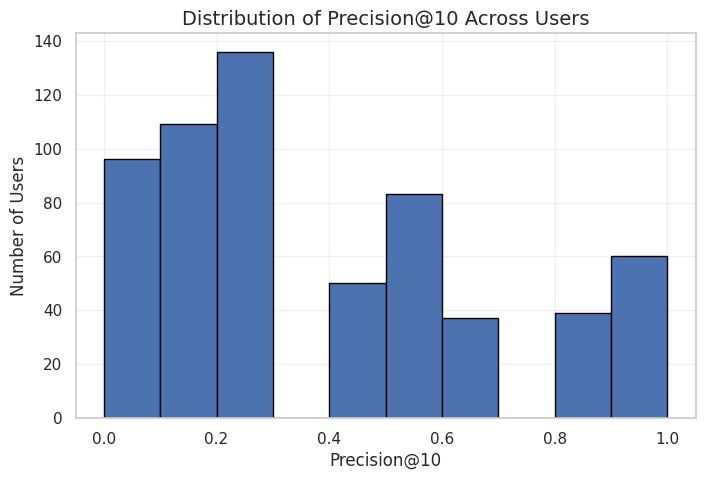

In [123]:
# ==========================================================
# Precision Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    list(precision_scores.values()),
    bins=10,
    edgecolor="black"
)

plt.title(
    "Distribution of Precision@10 Across Users",
    fontsize=14
)

plt.xlabel("Precision@10")

plt.ylabel("Number of Users")

plt.grid(alpha=0.3)
save_figure("Distribution of Precision@10 Across Users.png")


plt.show()

In [84]:
# ==========================================================
# Precision Summary
# ==========================================================

precision_summary = pd.DataFrame({

    "Metric": [
        "Users Evaluated",
        "Top-K",
        "Relevance Threshold",
        "Average Precision@10"
    ],

    "Value": [
        len(precision_scores),
        10,
        "Rating ≥ 4.0",
        round(average_precision, 4)
    ]

})

precision_summary

,Metric,Value
0,Users Evaluated,610
1,Top-K,10
2,Relevance Threshold,Rating ≥ 4.0
3,Average Precision@10,0.3672


In [85]:
# ==========================================================
# Popularity Recommendation List
# ==========================================================

popular_movie_ids = baseline_recommendations["movieId"].tolist()

print(f"Total Popular Movies : {len(popular_movie_ids)}")
print(f"Top 10 Movie IDs     : {popular_movie_ids[:10]}")

Total Popular Movies : 450
Top 10 Movie IDs     : [318, 858, 2959, 1276, 750, 904, 1221, 48516, 1213, 912]


In [86]:
# ==========================================================
# Popularity Baseline Precision@10
# ==========================================================

def popularity_precision_at_k(
    testset,
    popular_movie_ids,
    k=10,
    threshold=4.0
):

    from collections import defaultdict

    # Relevant movies for each user
    relevant_movies = defaultdict(set)

    for uid, iid, true_rating in testset:

        if true_rating >= threshold:

            relevant_movies[uid].add(iid)

    precisions = []

    for uid in relevant_movies.keys():

        recommended = set(popular_movie_ids[:k])

        relevant = relevant_movies[uid]

        if len(recommended) == 0:

            continue

        precision = len(
            recommended & relevant
        ) / k

        precisions.append(precision)

    return np.mean(precisions)

In [87]:
# ==========================================================
# Popularity Precision
# ==========================================================

baseline_precision = popularity_precision_at_k(

    testset,

    popular_movie_ids,

    k=10,

    threshold=4.0

)

print("=" * 50)

print("Popularity Baseline")

print("=" * 50)

print(f"Precision@10 : {baseline_precision:.4f}")

Popularity Baseline
Precision@10 : 0.0363


In [88]:
# ==========================================================
# Baseline Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model":[

        "Popularity Baseline",

        "User-Based CF"

    ],

    "RMSE":[

        "-",

        round(
            accuracy.rmse(
                predictions,
                verbose=False
            ),
            4
        )

    ],

    "Precision@10":[

        round(
            baseline_precision,
            4
        ),

        round(
            average_precision,
            4
        )

    ]

})

comparison

,Model,RMSE,Precision@10
0,Popularity Baseline,-,0.0363
1,User-Based CF,0.9823,0.3672


 Saved: images/Popularity Baseline vs User-Based CF.png


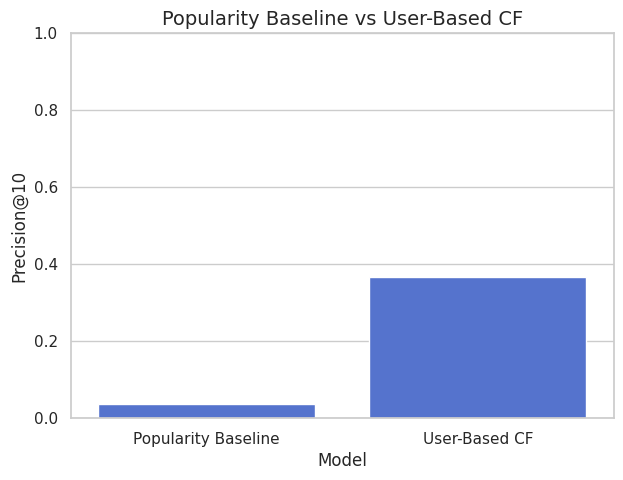

In [118]:
# ==========================================================
# Precision Comparison
# ==========================================================

plt.figure(figsize=(7,5))

sns.barplot(

    data=comparison,

    x="Model",

    y="Precision@10",

    color="royalblue"

)

plt.title(

    "Popularity Baseline vs User-Based CF",

    fontsize=14

)

plt.ylabel("Precision@10")

plt.ylim(0,1)

save_figure("Popularity Baseline vs User-Based CF.png")
plt.show()

Item-Based Collaborative Filtering

In [90]:
# ==========================================================
# Item-Based Collaborative Filtering Configuration
# ==========================================================

sim_options = {
    "name": "cosine",
    "user_based": False
}

item_model = KNNBasic(
    sim_options=sim_options,
    verbose=True
)

In [91]:
# ==========================================================
# Train Item-Based Collaborative Filtering
# ==========================================================

item_model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [92]:
# ==========================================================
# Generate Predictions
# ==========================================================

item_predictions = item_model.test(testset)

In [93]:
# ==========================================================
# RMSE Evaluation
# ==========================================================

item_rmse = accuracy.rmse(
    item_predictions,
    verbose=True
)

RMSE: 0.9800


In [94]:
# ==========================================================
# Organize Predictions by User
# ==========================================================

from collections import defaultdict

item_user_predictions = defaultdict(list)

for uid, iid, true_r, est, _ in item_predictions:

    item_user_predictions[uid].append(
        (iid, est, true_r)
    )

print(f"Users Evaluated : {len(item_user_predictions)}")

Users Evaluated : 610


In [95]:
# ==========================================================
# Precision@10
# ==========================================================

item_precision_scores = precision_at_k(
    item_user_predictions,
    k=10,
    threshold=4.0
)

item_average_precision = np.mean(
    list(item_precision_scores.values())
)

print("=" * 50)
print("Item-Based Collaborative Filtering")
print("=" * 50)

print(f"Average Precision@10 : {item_average_precision:.4f}")

Item-Based Collaborative Filtering
Average Precision@10 : 0.2164


 Saved: images/Precision@10 Distribution (Item-Based CF.png


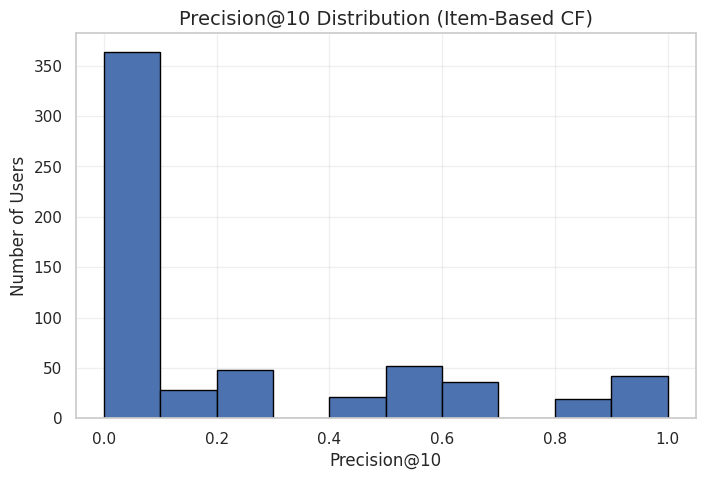

In [119]:
# ==========================================================
# Precision Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    list(item_precision_scores.values()),
    bins=10,
    edgecolor="black"
)

plt.title(
    "Precision@10 Distribution (Item-Based CF)",
    fontsize=14
)

plt.xlabel("Precision@10")
plt.ylabel("Number of Users")

plt.grid(alpha=0.3)
save_figure("Precision@10 Distribution (Item-Based CF.png")


plt.show()

In [97]:
# ==========================================================
# Item-Based Summary
# ==========================================================

item_summary = pd.DataFrame({

    "Metric":[
        "Users Evaluated",
        "RMSE",
        "Precision@10"
    ],

    "Value":[
        len(item_user_predictions),
        round(item_rmse,4),
        round(item_average_precision,4)
    ]

})

item_summary

,Metric,Value
0,Users Evaluated,610.0000
1,RMSE,0.9800
2,Precision@10,0.2164


In [98]:
# ==========================================================
# Matrix Factorization (SVD)
# ==========================================================

svd_model = SVD(

    random_state=42

)

In [99]:
# ==========================================================
# Train SVD Model
# ==========================================================

svd_model.fit(trainset)

In [100]:
# ==========================================================
# Generate Predictions
# ==========================================================

svd_predictions = svd_model.test(testset)

In [101]:
# ==========================================================
# RMSE Evaluation
# ==========================================================

svd_rmse = accuracy.rmse(

    svd_predictions,

    verbose=True

)

RMSE: 0.8807


In [102]:
# ==========================================================
# Organize Predictions
# ==========================================================

from collections import defaultdict

svd_user_predictions = defaultdict(list)

for uid, iid, true_r, est, _ in svd_predictions:

    svd_user_predictions[uid].append(

        (iid, est, true_r)

    )

print(f"Users Evaluated : {len(svd_user_predictions)}")

Users Evaluated : 610


In [103]:
# ==========================================================
# Precision@10
# ==========================================================

svd_precision_scores = precision_at_k(

    svd_user_predictions,

    k=10,

    threshold=4.0

)

svd_average_precision = np.mean(

    list(svd_precision_scores.values())

)

print("="*50)

print("Matrix Factorization (SVD)")

print("="*50)

print(f"Average Precision@10 : {svd_average_precision:.4f}")

Matrix Factorization (SVD)
Average Precision@10 : 0.3266


 Saved: images/Precision@10 Distribution (SVD).png


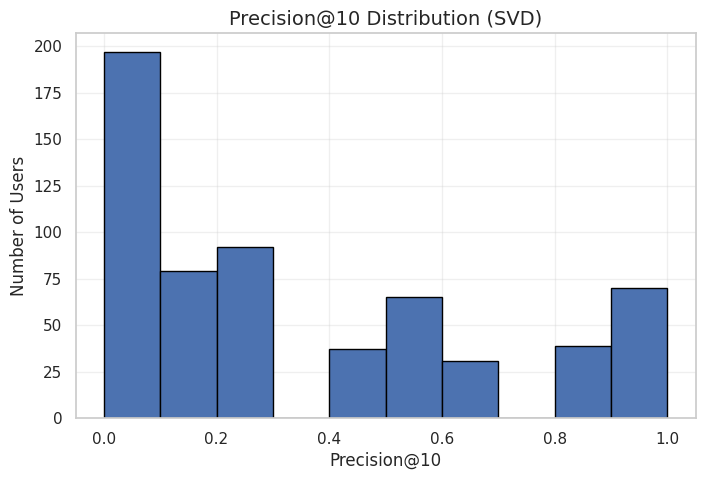

In [120]:
# ==========================================================
# Precision Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(

    list(svd_precision_scores.values()),

    bins=10,

    edgecolor="black"

)

plt.title(

    "Precision@10 Distribution (SVD)",

    fontsize=14

)

plt.xlabel("Precision@10")

plt.ylabel("Number of Users")

plt.grid(alpha=0.3)
save_figure("Precision@10 Distribution (SVD).png")

plt.show()

In [105]:
# ==========================================================
# SVD Summary
# ==========================================================

svd_summary = pd.DataFrame({

    "Metric":[

        "Users Evaluated",

        "RMSE",

        "Precision@10"

    ],

    "Value":[

        len(svd_user_predictions),

        round(svd_rmse,4),

        round(svd_average_precision,4)

    ]

})

svd_summary

,Metric,Value
0,Users Evaluated,610.0000
1,RMSE,0.8807
2,Precision@10,0.3266


In [106]:
# ==========================================================
# Final Model Comparison
# ==========================================================

final_results = pd.DataFrame({

    "Model": [

        "Popularity Baseline",
        "User-Based CF",
        "Item-Based CF",
        "Matrix Factorization (SVD)"

    ],

    "Category": [

        "Non-Personalized",
        "Memory-Based",
        "Memory-Based",
        "Model-Based"

    ],

    "RMSE": [

        np.nan,
        round(0.9823,4),
        round(0.9800,4),
        round(0.8807,4)

    ],

    "Precision@10": [

        round(0.0363,4),
        round(0.3672,4),
        round(0.2164,4),
        round(0.3266,4)

    ]

})

display(final_results)

,Model,Category,RMSE,Precision@10
0,Popularity Baseline,Non-Personalized,NaN,0.0363
1,User-Based CF,Memory-Based,0.9823,0.3672
2,Item-Based CF,Memory-Based,0.9800,0.2164
3,Matrix Factorization (SVD),Model-Based,0.8807,0.3266


In [107]:
# ==========================================================
# Model Ranking
# ==========================================================

ranking = final_results.copy()

ranking["RMSE Rank"] = ranking["RMSE"].rank(
    ascending=True,
    method="dense"
)

ranking["Precision Rank"] = ranking["Precision@10"].rank(
    ascending=False,
    method="dense"
)

display(ranking)

,Model,Category,RMSE,Precision@10,RMSE Rank,Precision Rank
0,Popularity Baseline,Non-Personalized,NaN,0.0363,NaN,4.0
1,User-Based CF,Memory-Based,0.9823,0.3672,3.0,1.0
2,Item-Based CF,Memory-Based,0.9800,0.2164,2.0,3.0
3,Matrix Factorization (SVD),Model-Based,0.8807,0.3266,1.0,2.0


 Saved: images/RMSE Comparison of Recommendation Models.png


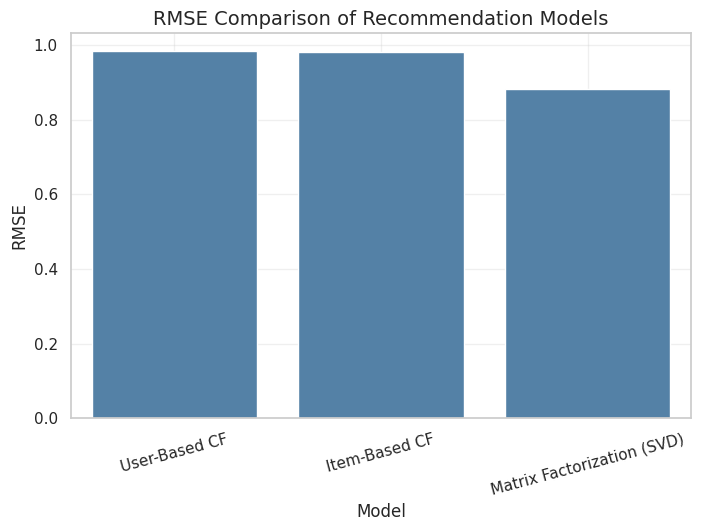

In [121]:
# ==========================================================
# RMSE Comparison
# ==========================================================

rmse_plot = final_results.dropna(subset=["RMSE"])

plt.figure(figsize=(8,5))

sns.barplot(
    data=rmse_plot,
    x="Model",
    y="RMSE",
    color="steelblue"
)

plt.title(
    "RMSE Comparison of Recommendation Models",
    fontsize=14
)

plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.grid(alpha=0.3)
save_figure("RMSE Comparison of Recommendation Models.png")


plt.show()

 Saved: images/Precision@10 Comparison of Recommendation Models.png


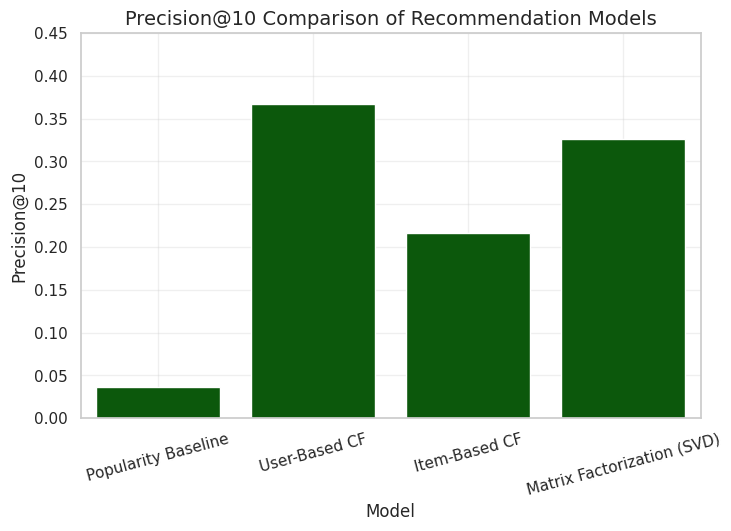

In [122]:
# ==========================================================
# Precision@10 Comparison
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=final_results,
    x="Model",
    y="Precision@10",
    color="darkgreen"
)

plt.title(
    "Precision@10 Comparison of Recommendation Models",
    fontsize=14
)

plt.ylabel("Precision@10")

plt.xticks(rotation=15)

plt.ylim(0,0.45)

plt.grid(alpha=0.3)
save_figure("Precision@10 Comparison of Recommendation Models.png")


plt.show()

In [110]:
# ==========================================================
# Best Model Summary
# ==========================================================

summary = pd.DataFrame({

    "Evaluation Metric":[

        "Best RMSE",
        "Best Precision@10",
        "Best Rating Prediction",
        "Best Recommendation Quality"

    ],

    "Winning Model":[

        "Matrix Factorization (SVD)",
        "User-Based CF",
        "Matrix Factorization (SVD)",
        "User-Based CF"

    ],

    "Score":[

        "0.8807",
        "0.3672",
        "Lowest RMSE",
        "Highest Precision@10"

    ]

})

display(summary)

,Evaluation Metric,Winning Model,Score
0,Best RMSE,Matrix Factorization (SVD),0.8807
1,Best Precision@10,User-Based CF,0.3672
2,Best Rating Prediction,Matrix Factorization (SVD),Lowest RMSE
3,Best Recommendation Quality,User-Based CF,Highest Precision@10


In [111]:
# ==========================================================
# Executive Performance Dashboard
# ==========================================================

print("="*70)
print("FINAL RECOMMENDATION SYSTEM PERFORMANCE DASHBOARD")
print("="*70)

print(f"Dataset                 : MovieLens Latest-Small")
print(f"Users                   : 610")
print(f"Movies                  : 9,742")
print(f"Ratings                 : 100,836")
print()

print(f"Popularity Precision@10 : 0.0363")
print(f"User-Based Precision@10 : 0.3672")
print(f"Item-Based Precision@10 : 0.2164")
print(f"SVD Precision@10        : 0.3266")
print()

print(f"User-Based RMSE         : 0.9823")
print(f"Item-Based RMSE         : 0.9800")
print(f"SVD RMSE                : 0.8807")

print("="*70)

FINAL RECOMMENDATION SYSTEM PERFORMANCE DASHBOARD
Dataset                 : MovieLens Latest-Small
Users                   : 610
Movies                  : 9,742
Ratings                 : 100,836

Popularity Precision@10 : 0.0363
User-Based Precision@10 : 0.3672
Item-Based Precision@10 : 0.2164
SVD Precision@10        : 0.3266

User-Based RMSE         : 0.9823
Item-Based RMSE         : 0.9800
SVD RMSE                : 0.8807
